### Analysis of learned plasticity rule that organizes integrating network
Networks initialized with structured input weights, but weights in 'ellipsoid body' are random but fully connected.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns


CELL_TYPE_1_SIZE = 5

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS = [
    'sims_out/n5_short_min_pactive_0p25_test_000672_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-08_18:20:45.671641_run_None',
    'sims_out/n5_short_min_pactive_0p25_test_000677_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-08_18:20:45.827346_run_None',
    'sims_out/n5_short_min_pactive_0p25_test_000678_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-08_18:20:45.822338_run_None',
    'sims_out/n5_short_min_pactive_0p25_test_000679_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-08_18:20:54.561204_run_None',
]

DATA_PATHS_HET_SHORT = [
    'sims_out/n5_short_min_pactive_0p25_test_000643_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-08_16:11:54.355580_run_None',
    'sims_out/n5_short_min_pactive_0p25_test_000646_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-08_16:11:54.355574_run_None',
    'sims_out/n5_short_min_pactive_0p25_test_000649_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-08_16:11:54.355580_run_None',
]

DATA_PATHS_NO_HET_LONG = [
    'sims_out/n5_long_min_pactive_0p25_test_000683_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-06_10:46:24.969537_run_None',
]

In [2]:
def load_numpy(data_path, last_n=None):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    if last_n is not None:
        data = data[-last_n:]
    data = np.stack(data)
    return data

def make_path_if_not_exists(path_str):
    Path(path_str).mkdir(parents=True, exist_ok=True)

def load_r_and_int_values(rule_path, net_path, last_n=100):
    all_r = np.stack(load_numpy(os.path.join(rule_path, 'activities', net_path), last_n=last_n)).squeeze()
    all_int_values = np.stack(load_numpy(os.path.join(rule_path, 'integrated_values', net_path), last_n=last_n)).squeeze()
    
    if last_n is not None:
        last_n_r = all_r[-last_n:, 200:, :CELL_TYPE_1_SIZE]
        all_int_values = all_int_values[-last_n:, :]
    else:
        last_n_r = all_r[:, 200:, :CELL_TYPE_1_SIZE]
        
    last_n_r = np.transpose(last_n_r, [2, 0, 1])

    return last_n_r, all_int_values

def load_targets_and_predictions(rule_path, net_path, last_n):
    predictions = np.stack(load_numpy(os.path.join(rule_path, 'predictions', net_path), last_n=last_n)).squeeze()
    targets = np.stack(load_numpy(os.path.join(rule_path, 'targets', net_path), last_n=last_n)).squeeze()

    return targets, predictions

### Analysis of weights

In [4]:
from matplotlib.colors import TwoSlopeNorm

def plot_step(run, v=6, save_name=None, mask=None, scale=3):
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    
    cmap = sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True)

    # Use TwoSlopeNorm to ensure white maps to 0
    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
    
    # Plot the matrix
    if mask is None:
        im = axs.matshow(all_w[run, ...], cmap=cmap, norm=norm)
    else:
        print(all_w[run, ...][mask, :][:, mask])
        im = axs.matshow(all_w[run, ...][mask, :][:, mask], cmap=cmap, norm=norm)

    # Ticks and labels
    # axs.set_xticks([15, 30, 45])
    # axs.set_yticks([15, 30, 45])
    axs.tick_params(axis='both')
    axs.set_xlabel('Presynaptic')
    axs.set_ylabel('Postsynaptic')
    axs.xaxis.set_label_position('top')
    axs.tick_params(axis='x', bottom=False)
    axs.tick_params(axis='both', length=10)
    axs.spines['right'].set_visible(False)
    axs.spines['bottom'].set_visible(False)

    axs.set_xticks([0, 5, 10, 15])
    axs.set_yticks([0, 5, 10, 15])

    # Add colorbar
    cbar = fig.colorbar(im, ax=axs, fraction=0.046, pad=0.04)
    cbar.set_label('Weight')

    format_plot(axs, topspine=True, rightspine=True)
    format_plot(cbar.ax)

    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')

    return fig

In [5]:
# # Directory to save frames
# frames_dir = "./weight_evo"
# os.makedirs(frames_dir, exist_ok=True)

# # Parameters
# num_runs = 320
# timestep = 0

# # Generate and save plots as images
# for run in range(num_runs):
#     fig = plot_step(run)
#     fig.tight_layout()
#     frame_path = os.path.join(frames_dir, f"frame_{run:03}_{timestep:04}.png")
#     fig.tight_layout()
#     fig.savefig(frame_path)
#     plt.close(fig)  # Free memory

In [6]:
# # Parameters
# image_folder = './weight_evo'     # directory with images
# output_video = 'output.mp4'       # output filename
# fps = 30                          # frames per second

# # Get all .png files, sorted naturally
# images = [img for img in os.listdir(image_folder) if img.endswith(".png")]
# images = natsorted(images)  # natural sort: img1, img2, ..., img10

# # Read first image to get dimensions
# first_frame = cv2.imread(os.path.join(image_folder, images[0]))
# height, width, layers = first_frame.shape

# # Define the video writer
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # or 'XVID' for .avi
# video = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# # Add frames
# for image in images:
#     frame = cv2.imread(os.path.join(image_folder, image))
#     video.write(frame)

# video.release()
# print("Video written to", output_video)

(420, 16, 16)
(420, 16, 16)
(420, 16, 16)
(420, 16, 16)


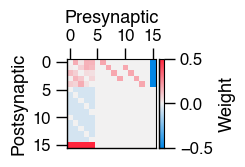

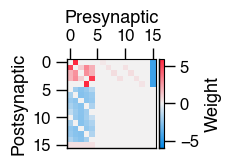

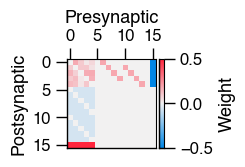

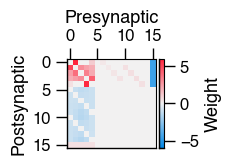

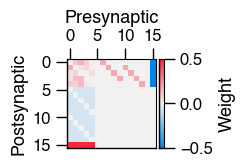

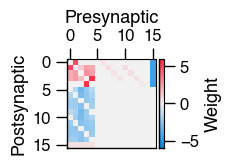

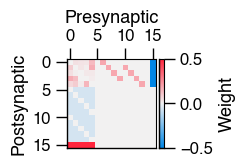

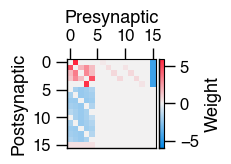

In [13]:
for i, dp in enumerate(DATA_PATHS):
    all_w = load_numpy(os.path.join(dp, 'weights/net_009.npy')).squeeze(0)

    print(all_w.shape)

    f = plot_step(0, save_name=f'./figures/n5_no_het_short_initial_weight_mat_{i}.svg', v=0.5, scale=1.25)
    f = plot_step(410, save_name=f'./figures/n5_no_het_short_final_weight_mat_{i}.svg', v=6, scale=1.25)

(420, 16, 16)
(420, 16, 16)
(420, 16, 16)


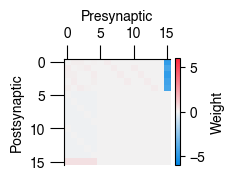

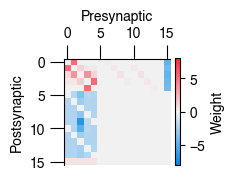

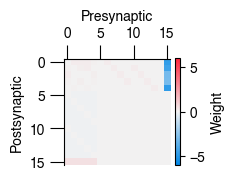

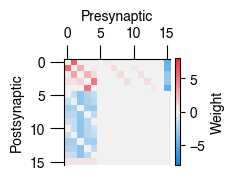

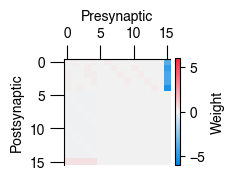

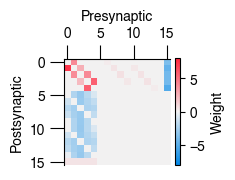

In [26]:
for i, dp in enumerate(DATA_PATHS_HET_SHORT):
    all_w = load_numpy(os.path.join(dp, 'weights/net_009.npy')).squeeze(0)

    print(all_w.shape)

    f = plot_step(0, save_name=f'./figures/n5_het_short_initial_weight_mat_{i}.svg', scale=1.5)
    f = plot_step(410, save_name=f'./figures/n5_het_short_final_weight_mat_{i}.svg', v=8, scale=1.5)

(420, 16, 16)


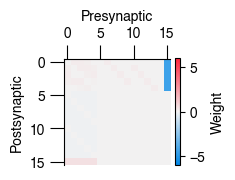

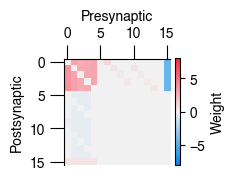

In [5]:
for i, dp in enumerate(DATA_PATHS_NO_HET_LONG):
    all_w = load_numpy(os.path.join(dp, 'weights/net_009.npy')).squeeze(0)

    print(all_w.shape)

    f = plot_step(0, save_name=f'./figures/n5_no_het_long_initial_weight_mat_{i}.svg', scale=1.5)
    f = plot_step(410, save_name=f'./figures/n5_no_het_long_final_weight_mat_{i}.svg', v=8, scale=1.5)

### Epoch over epoch weight change

In [13]:
def graph_epoch_over_epoch_weight_change(dps, k=5, save_name=None):
    fig, axs = plt.subplots(len(dps), 1, sharex=True, sharey=True, figsize=(3, len(dps) * 1))
    axs = np.atleast_1d(axs)
    for i, dp in enumerate(dps):
        all_w = load_numpy(os.path.join(dp, f'weights/net_00{k}.npy')).squeeze()
        all_w_trimmed = all_w[:, :CELL_TYPE_1_SIZE, :CELL_TYPE_1_SIZE]
        diffs = np.linalg.norm(all_w_trimmed[1:, ...] - all_w_trimmed[:-1, ...], axis=(1, 2))
        denoms = np.linalg.norm(all_w_trimmed[:-1, ...], axis=(1, 2))
        normed_diffs = diffs / denoms
        axs[i].plot(np.arange(len(normed_diffs)), normed_diffs)
    axs[0].set_ylabel(r'$\frac{\left\| \Delta W \right\| }{ \left\| W \right\| }$')
    axs[-1].set_xlabel('Epoch')
    axs[0].set_yscale('log')
    axs[0].set_xlim(0)
    axs[0].set_ylim(1e-3, 1)
    format_plot(axs)
    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')

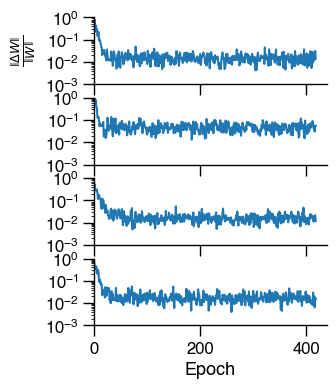

In [14]:
graph_epoch_over_epoch_weight_change(DATA_PATHS, save_name='./figures/n5_no_het_short_weight_change.svg')

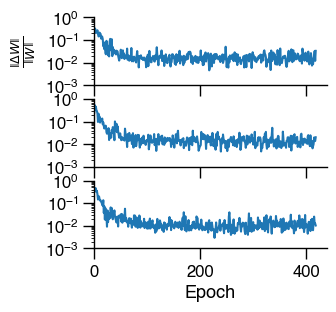

In [15]:
graph_epoch_over_epoch_weight_change(DATA_PATHS_HET_SHORT, save_name='./figures/n5_het_short_weight_change.svg')

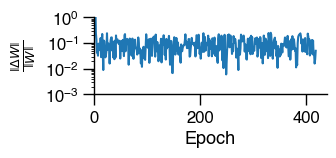

In [16]:
graph_epoch_over_epoch_weight_change(DATA_PATHS_NO_HET_LONG, save_name='./figures/n5_no_het_long_weight_change.svg')

### Analysis of neural activity

In [30]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

def plot_3d_surface(ending_states, int_values_for_ending_states, save_name=None):
    scale = 4
    fig = plt.figure(figsize=(1 * scale, 1 * scale))
    ax = fig.add_subplot(111, projection='3d')

    num_neurons = ending_states.shape[0]
    num_lines = ending_states.shape[1]

    # Create grid for surface
    X = np.arange(num_neurons)[:, None]                       # shape (neurons, 1)
    Y = int_values_for_ending_states[None, :]                 # shape (1, lines)
    X, Y = np.meshgrid(np.arange(num_neurons),
                       int_values_for_ending_states,
                       indexing='ij')                         # both (neurons, lines)

    Z = ending_states                                          # already shaped (neurons, lines)

    # Plot surface
    surf = ax.plot_surface(
        X, Y, Z,
        cmap='viridis',
        edgecolor='none',
        linewidth=0,
        antialiased=True
    )

    # Labels
    ax.set_xlabel("Neuron")
    ax.set_ylabel("Integrated value")
    ax.set_zlabel("Firing rate (Hz)")

    fig.colorbar(surf, shrink=0.6, pad=0.1)

    if save_name is not None:
        fig.savefig(save_name + "_firing_rates_surface.svg", bbox_inches="tight")

In [31]:
def make_tuning_curves(last_100_r, all_int_values, save_name=None):
    ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))
    int_values_for_ending_states = np.empty((all_int_values.shape[0]))
    for i, j in enumerate(np.argsort(all_int_values[:, -50])):
        ending_states[:, i] = last_100_r[:, j, -50]
        int_values_for_ending_states[i] = all_int_values[j, -50]
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    m = np.abs(ending_states).max()
    
    axs.matshow(ending_states, cmap='bwr', vmin=-m, vmax=m, aspect=15)
    
    format_plot(axs, rightspine=True, topspine=True)
    
    axs.set_xlabel('Integrated sum')
    axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
    axs.set_ylabel('Neuron')
    axs.set_yticks([0, CELL_TYPE_1_SIZE - 1])
    axs.tick_params(axis='both', length=6)

    if save_name is not None:
        fig.savefig(save_name + '_tuning_curve_matshow.svg', bbox_inches='tight')

    scale = 2
    n_lines = ending_states.shape[0]
    fig, axs = plt.subplots(n_lines, 1, figsize=(1 * scale, 0.5 * scale * n_lines), sharex=True)
    
    # Handle case where there's only one subplot (axs won't be an array)
    if n_lines == 1:
        axs = [axs]
    
    for i in range(n_lines):
        axs[i].plot(int_values_for_ending_states, ending_states[i, :], lw=0.5, alpha=0.3)
        axs[i].scatter(int_values_for_ending_states, ending_states[i, :], s=3)
        format_plot(axs[i])
    
    # Only show x-label on bottom subplot
    axs[-1].set_xlabel(r'$\int \left( I_{\rm R} - I_{\rm L} \right)$')
    axs[2].set_ylabel('Rate (Hz)')
    
    plt.tight_layout()

    if save_name is not None:
        fig.savefig(save_name + '_tuning_curve.svg', bbox_inches='tight')

    scale = 2
    n_lines = ending_states.shape[0]
    fig, axs = plt.subplots(n_lines, 1, figsize=(1 * scale, 0.5 * scale * n_lines), sharex=True, sharey=True)
    if n_lines == 1:
        axs = [axs]
    bins = 10
    
    for i in range(n_lines):
    
        # Compute histogram bin edges
        _, bin_edges = np.histogram(int_values_for_ending_states, bins=bins)
    
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bar_width = bin_edges[1] - bin_edges[0]
    
        for b in range(bins):
            low = bin_edges[b]
            high = bin_edges[b+1]
            # Which entries fall in this bin?
            mask = (int_values_for_ending_states >= low) & (int_values_for_ending_states < high)
            # Values for this line
            vals = ending_states[i, mask]
            # Filter out zeros
            nonzero_vals = vals[vals != 0]
            # Skip bins with no nonzero entries
            if nonzero_vals.size == 0:
                continue
    
            # Mean + SEM
            mean = np.mean(nonzero_vals)
            sem = np.std(nonzero_vals) / np.sqrt(len(nonzero_vals))
    
            # Draw bar
            # axs[i].bar(bin_centers[b], mean,
            #            width=bar_width,
            #            alpha=1,
            #            color='#1b62a4',
            #            edgecolor='#1b62a4',
            #            linewidth=0.5)
    
            # Draw error bar
            axs[i].errorbar(bin_centers[b], mean, yerr=sem,
                            fmt='k.', capsize=0, color='black')
        plt.tight_layout()
    
    # Only show x-label on bottom subplot
    axs[-1].set_xlabel(r'$\int \left( I_{\rm R} - I_{\rm L} \right)$')
    axs[2].set_ylabel('Rate (Hz)')
    format_plot(axs)
    plt.tight_layout()

    if save_name is not None:
        fig.savefig(save_name + '_tuning_curve_hist.svg', bbox_inches='tight')
    
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    int_min, int_max = int_values_for_ending_states.min(), int_values_for_ending_states.max()
    colors = [cmap((int_values_for_ending_states[i] - int_min) / (int_max - int_min))[:3] for i in range(100)]  # 49 to include 0 and 1
    
    for i in range(ending_states.shape[1]):
        axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)

    norm = matplotlib.colors.Normalize(vmin=int_min, vmax=int_max)
    sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Only needed for older versions of matplotlib
    cbar = fig.colorbar(sm, ax=axs, orientation='vertical', pad=0.02)
    cbar.set_label("Integrated value")
    format_plot(cbar.ax)
    
    format_plot(axs)
    
    axs.set_ylabel('Firing rate (Hz)')
    axs.set_xlabel('Neuron')
    axs.set_xticks([0, CELL_TYPE_1_SIZE - 1])
    axs.set_xlim(0, CELL_TYPE_1_SIZE - 1)
    axs.tick_params(axis='both', length=6)

    if save_name is not None:
        fig.savefig(save_name + '_firing_rates.svg', bbox_inches='tight')

    plot_3d_surface(ending_states, int_values_for_ending_states)

In [32]:
def make_stability_plot(last_100_r, all_int_values, save_name=None):
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    scale = 3

    if all_int_values.shape[-1] < last_100_r.shape[-1]:
        all_int_values = np.concatenate([
            all_int_values,
            all_int_values[:,-1:] * np.ones((all_int_values.shape[0], last_100_r.shape[-1] - all_int_values.shape[-1])),
        ], axis=1)

    def normed_loc(raster):
        total_activity = raster.sum(axis=0)
        raster_normed = np.divide(
            raster,
            total_activity[None, ...],
            where=total_activity != 0,
            out=np.zeros_like(raster)
        )
        ordered_indices = np.argsort(raster, axis=0)
        max_5_indices = ordered_indices[-13:, :]
        x = np.arange(raster_normed.shape[0])
        cols = np.arange(raster.shape[1])[None, :]
        locs = np.einsum(
            'ij,ij->j',
            x[max_5_indices],
            raster_normed[max_5_indices, cols],
        )
        return locs

    all_final_traj = []

    # Create a figure with 2 columns: main plot and histogram
    fig = plt.figure(figsize=(1.3 * scale, 0.45 * scale))
    gs = gridspec.GridSpec(1, 2, width_ratios=[5, 1], wspace=0.05)
    ax_main = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

    sorted_int_values = []

    # Use global color normalization for consistent coloring
    global_max = np.max(np.abs(all_int_values))
    norm = matplotlib.colors.Normalize(vmin=-global_max, vmax=global_max)
    all_traj = []
    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        traj = normed_loc(last_100_r[:, j, :])
        all_final_traj.append(traj[-1])
        cbar = ax_main.plot(
            np.arange(all_int_values.shape[1]),
            traj,
            alpha=0.5,
            color=cmap(norm(all_int_values[j, -1])),
        )
        
        sorted_int_values.append(all_int_values[j, :])
        all_traj.append(traj)
    all_traj = np.stack(all_traj)

    # Main plot formatting
    ax_main.set_xlabel('Time (ms)')
    ax_main.set_ylabel('Bump location')
    ax_main.set_xticks(np.arange(0, 1301, 1000))
    ax_main.set_xticklabels((np.arange(0, 1301, 1000) / 10).astype(int))
    center_point = 0.5 * CELL_TYPE_1_SIZE
    m = np.maximum(center_point - all_traj.min(), all_traj.max() - center_point)
    ax_main.set_ylim(center_point - m * 1.1, center_point + m * 1.1)
    ax_main.set_xlim(0)
    # ax_main.tick_params(axis='both', length=6, labelsize=14)
    format_plot(ax_main) #, ticklabelsize=16, axislabelsize=16)

    # Histogram on the right (rotated)
    bins = np.arange(30) / 30 * (CELL_TYPE_1_SIZE - 1)
    ax_hist.hist(all_final_traj, bins=bins, orientation='horizontal', color='gray')
    ax_hist.set_xlabel('Count')
    ax_hist.tick_params(axis='x')
    ax_hist.tick_params(axis='y', labelleft=False)  # Hide y-axis labels to avoid duplication
    format_plot(ax_hist)

    if save_name is not None:
        fig.savefig(save_name + '_stability_plot.svg', bbox_inches='tight')

    plt.show()

    fig, axs = plt.subplots(1, 1, figsize=(0.5 * scale, 0.5 * scale))

    # axs.plot([-m, m], [-m, m], color='black', zorder=0)
    axs.scatter(np.stack(sorted_int_values)[:, -1], all_final_traj, s=3, zorder=1, facecolor='red', edgecolor='red', alpha=0.5)
    # axs.set_xlim(-m, m)
    # axs.set_ylim(-m, m)
    # axs.set_xticks([-100, 0, 100])
    # axs.set_yticks([-100, 0, 100])
    # axs.set_ylim(-0.05, 1.05)
    format_plot(axs)

    axs.set_xlabel(r'$\int \left( I_{\rm R} - I_{\rm L} \right)$') #, fontsize=16)
    axs.set_ylabel('Bump location') # , fontsize=16)
    # axs.set_title('Predicted vs true integrated sums', fontsize=16)
    # axs.tick_params(axis='both', length=6,)

    if save_name is not None:
        fig.savefig(save_name + '_bump_vs_value.svg', bbox_inches='tight')


In [58]:
def plot_targets_vs_predictions(dp, save_name=None):
    targets, predictions = load_targets_and_predictions(dp, f'net_00{k}.npy', last_n=100)

    scale = 3
    fig, axs = plt.subplots(1, 1, figsize=(0.5 * scale, 0.5 * scale))

    axs.scatter(targets[119::120], predictions[119::120], s=3, zorder=1, facecolor='red', edgecolor='red', alpha=0.5)

    axs.set_xlabel(r'$\int \left( I_{\rm R} - I_{\rm L} \right)$') #, fontsize=16)
    axs.set_ylabel('Predicted') # , fontsize=16)
    format_plot(axs)
    # axs.set_title('Predicted vs true integrated sums', fontsize=16)
    # axs.tick_params(axis='both', length=6,)
    # Compute joint bounds
    t = targets[119::120]
    p = predictions[119::120]
    lo = min(t.min(), p.min())
    lo = 0.9 * lo if lo >= 0 else 1.1 * lo
    hi = max(t.max(), p.max())
    hi = 1.1 * hi if hi >= 0 else 0.9 * hi

    # Use same limits for x and y
    axs.set_xlim(lo, hi)
    axs.set_ylim(lo, hi)

    axs.plot([lo, hi], [lo, hi], '--', c='grey', zorder=-1)

    if save_name is not None:
        fig.savefig(save_name + '_pred_vs_value.svg', bbox_inches='tight')

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



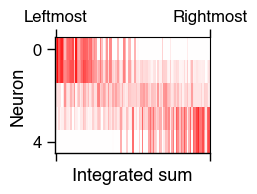

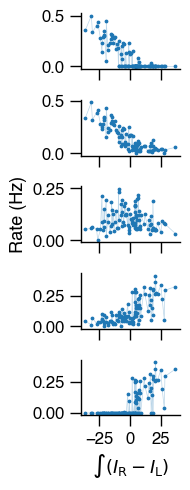

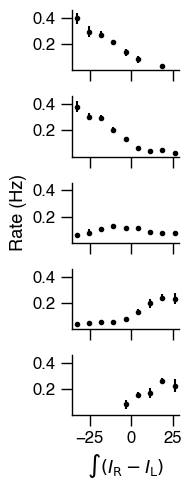

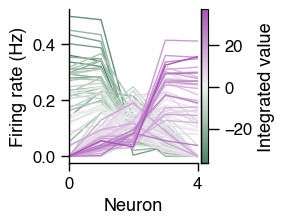

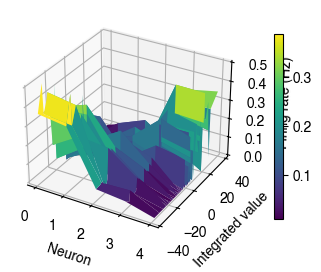

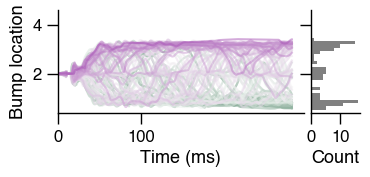

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



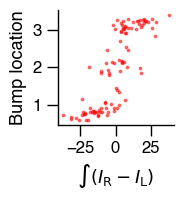

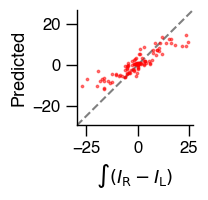

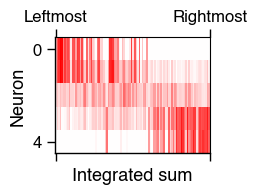

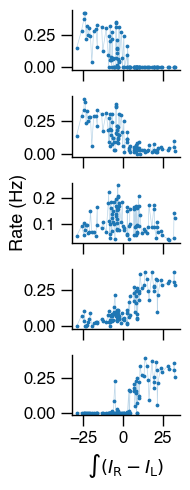

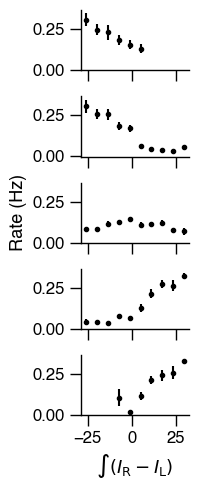

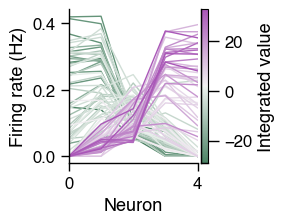

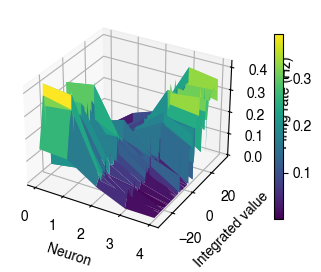

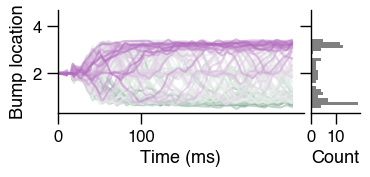

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



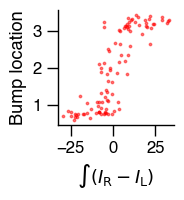

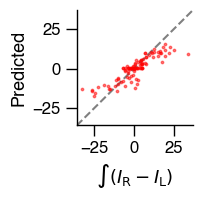

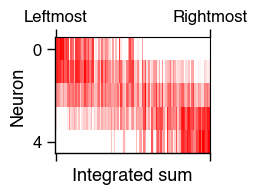

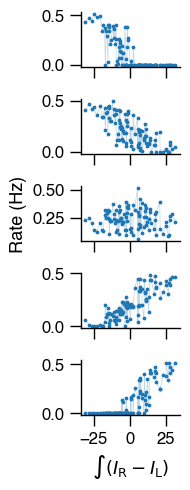

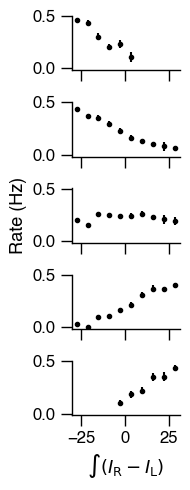

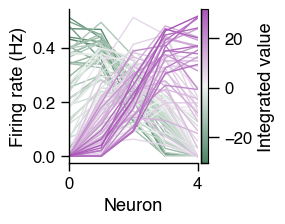

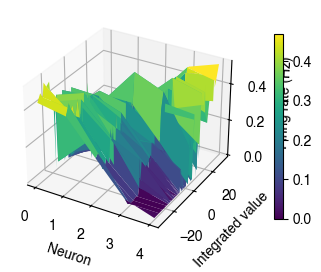

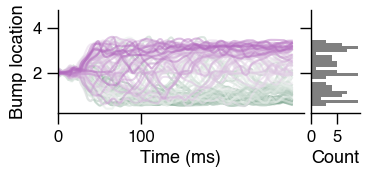

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



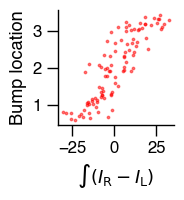

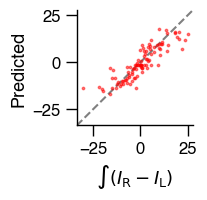

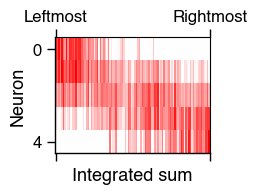

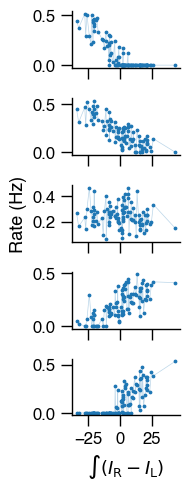

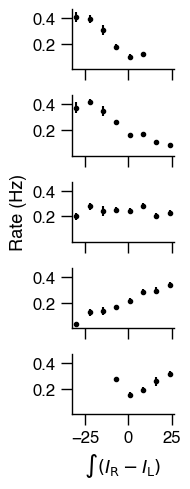

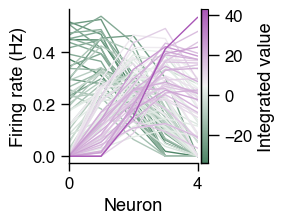

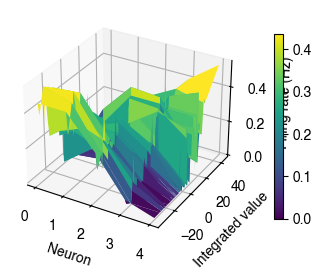

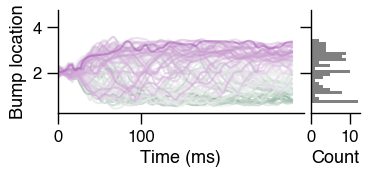

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



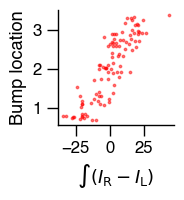

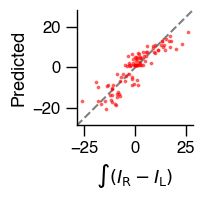

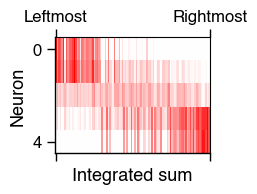

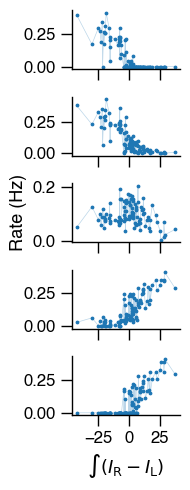

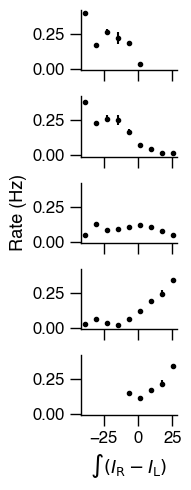

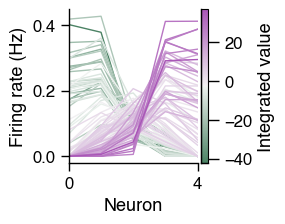

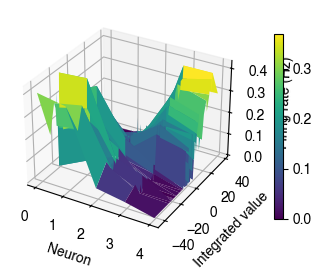

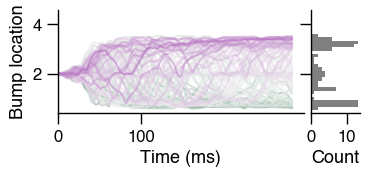

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



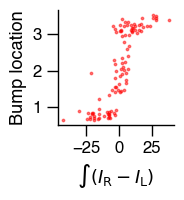

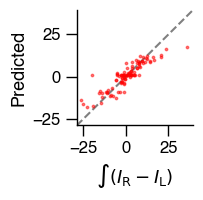

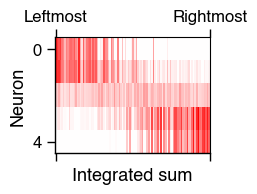

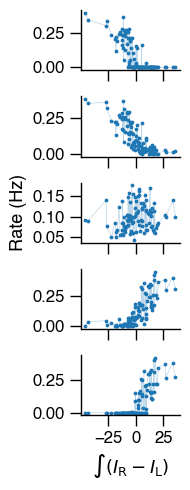

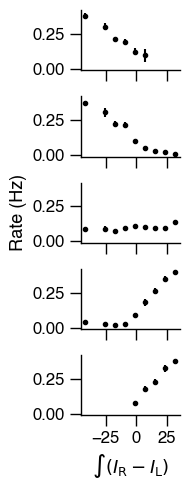

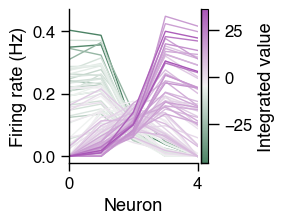

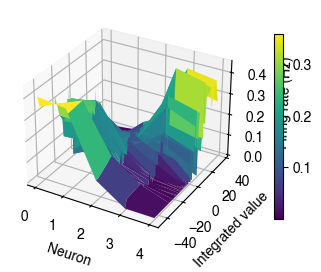

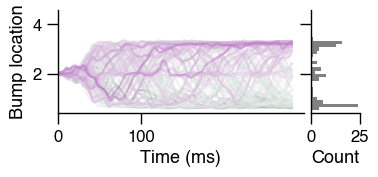

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



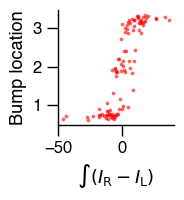

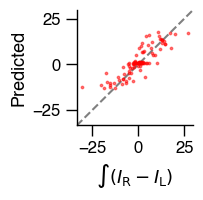

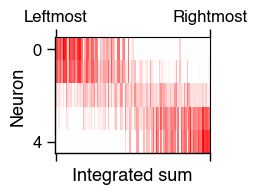

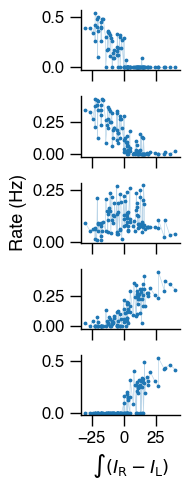

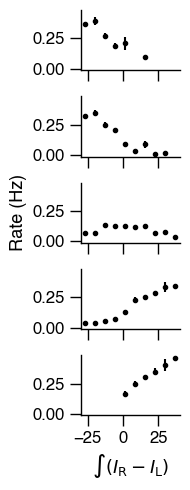

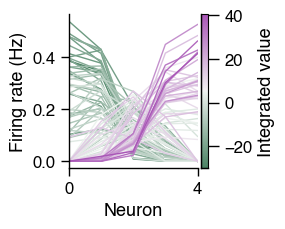

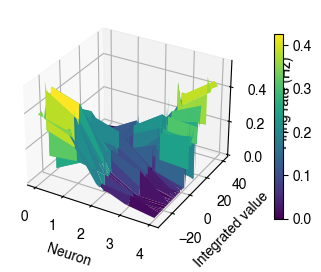

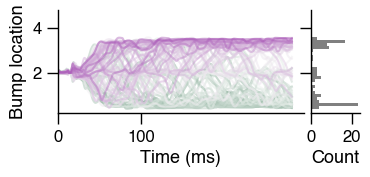

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



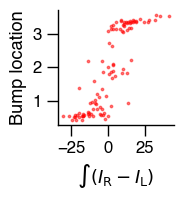

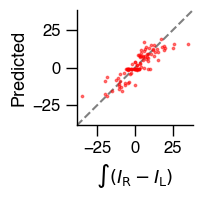

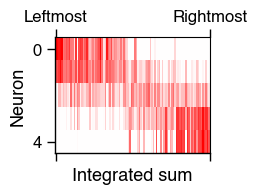

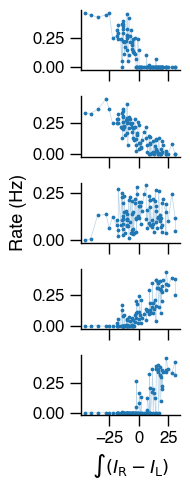

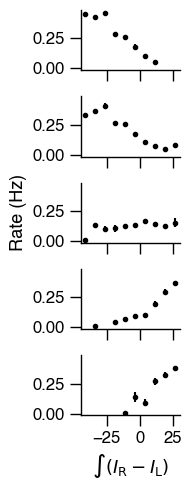

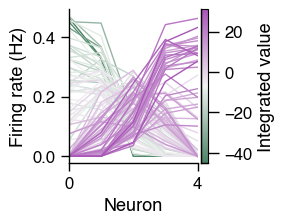

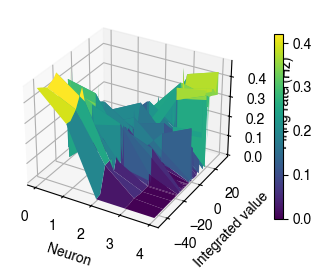

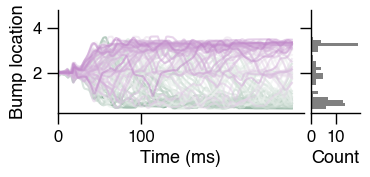

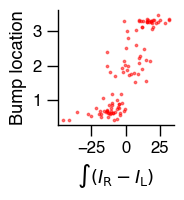

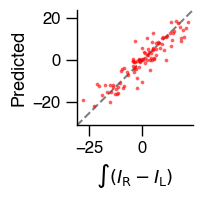

In [59]:
for i, dp in enumerate(DATA_PATHS):
    for k in np.arange(8, 10):
        last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{k}.npy', last_n=100)
        make_tuning_curves(
            last_100_r,
            all_int_values,
            save_name=f'./figures/n5_no_het_short_{i}_index_{k}',
        )
        make_stability_plot(last_100_r, all_int_values, save_name=f'./figures/n5_no_het_short_{i}_index_{k}')
        plot_targets_vs_predictions(dp, save_name=f'./figures/n5_no_het_short_{i}_index_{k}')

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



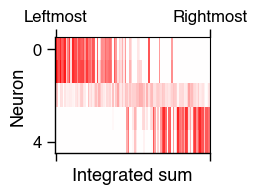

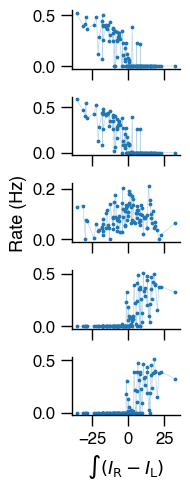

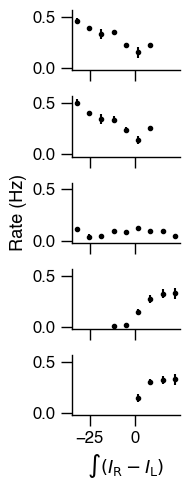

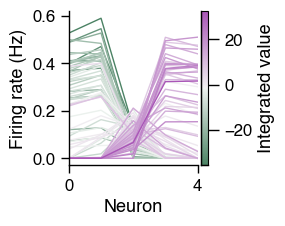

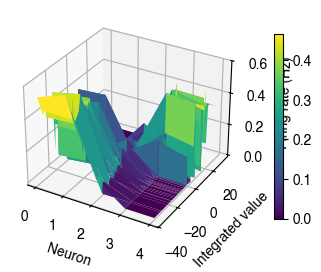

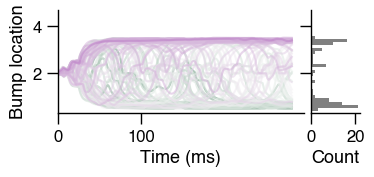

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



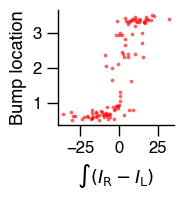

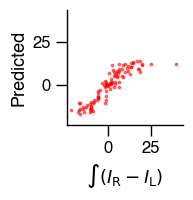

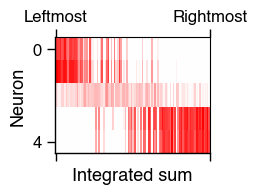

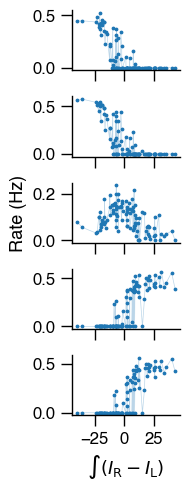

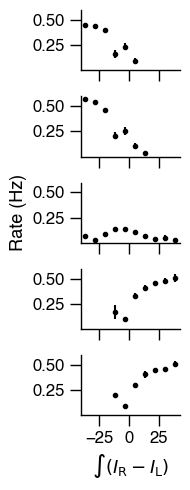

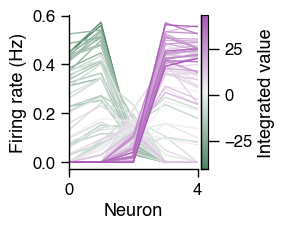

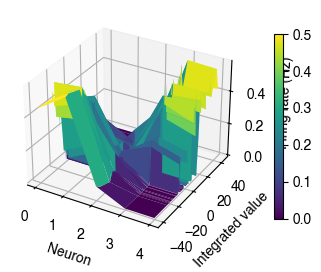

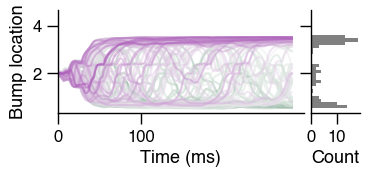

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



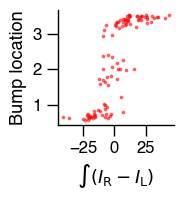

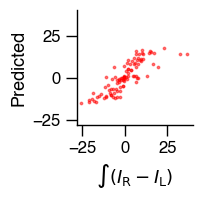

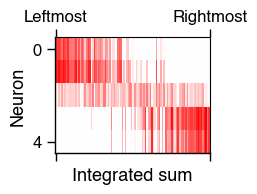

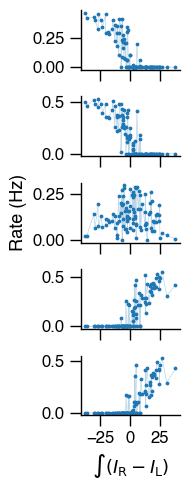

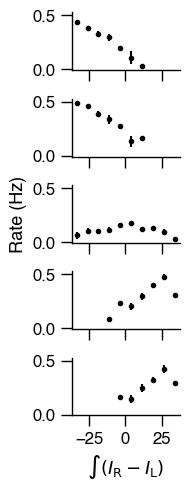

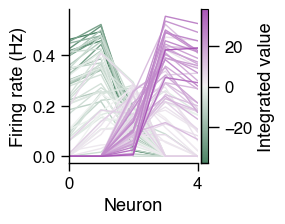

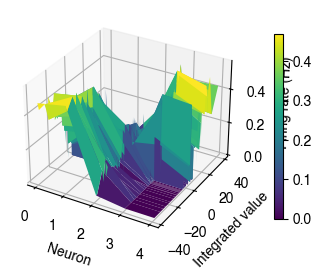

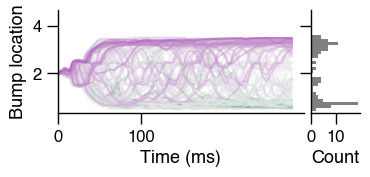

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



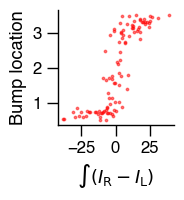

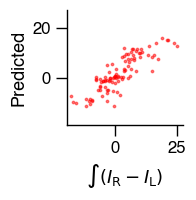

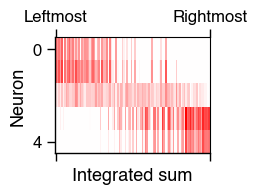

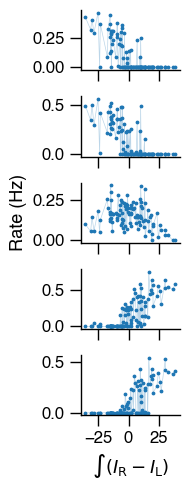

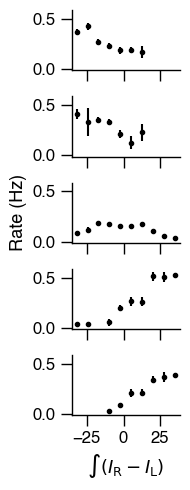

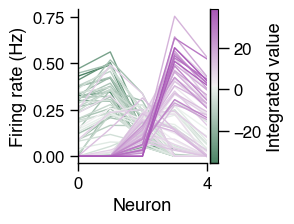

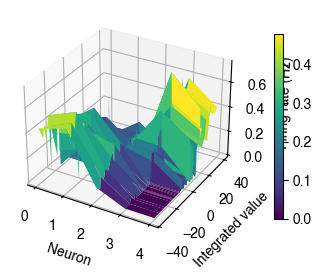

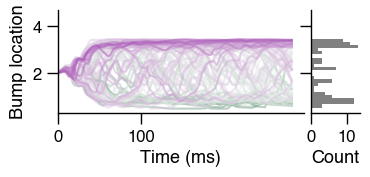

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



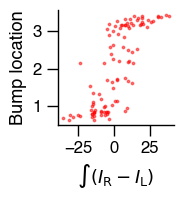

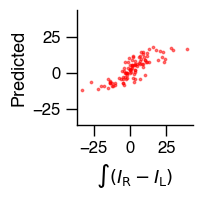

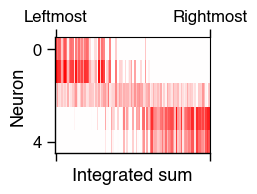

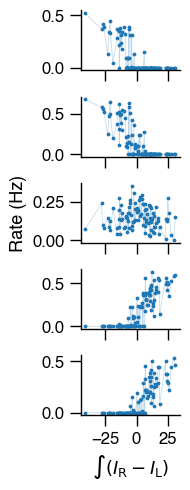

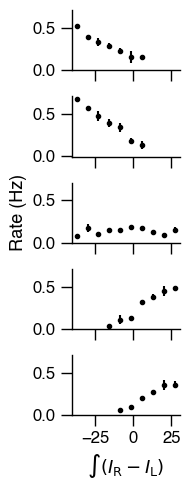

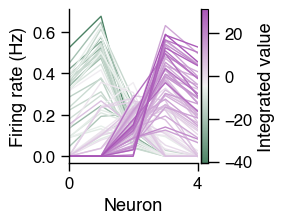

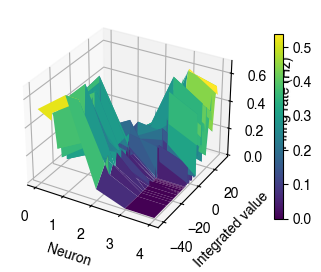

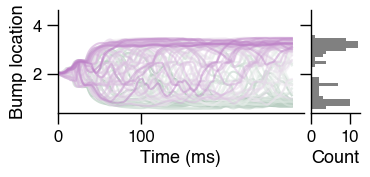

/tmp/ipykernel_939965/2730688749.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



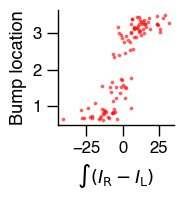

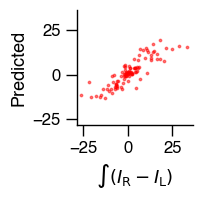

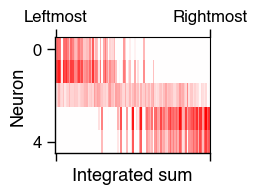

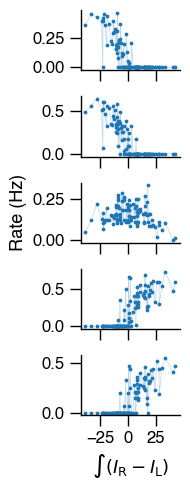

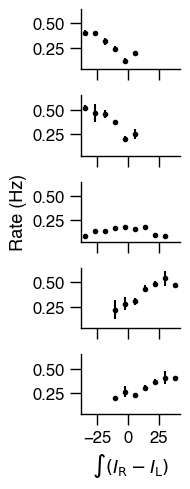

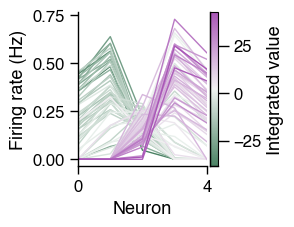

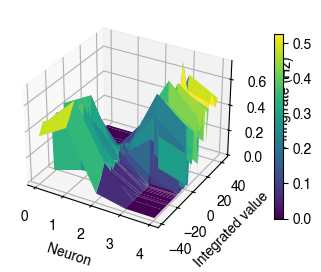

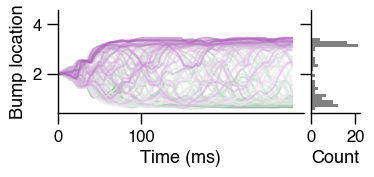

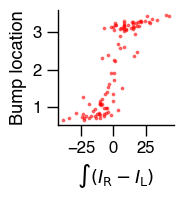

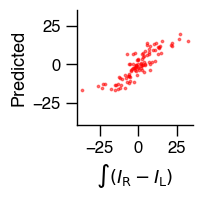

In [43]:
for i, dp in enumerate(DATA_PATHS_HET_SHORT):
    for k in np.arange(8, 10):
        last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{k}.npy', last_n=100)
        make_tuning_curves(
            last_100_r,
            all_int_values,
            save_name=f'./figures/n5_het_short_{i}_index_{k}',
        )
        make_stability_plot(last_100_r, all_int_values, save_name=f'./figures/n5_het_short_{i}_index_{k}')
        plot_targets_vs_predictions(dp)

/tmp/ipykernel_3405132/3987796810.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



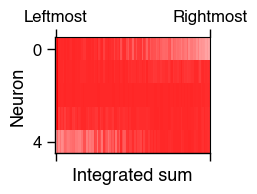

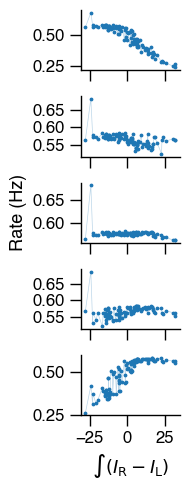

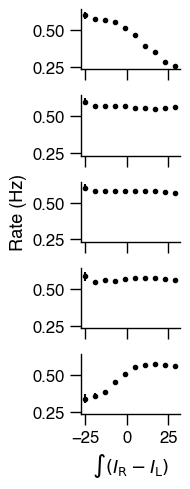

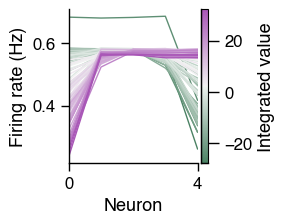

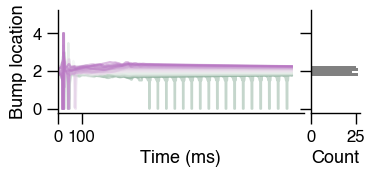

/tmp/ipykernel_3405132/3987796810.py:88: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.



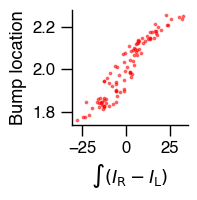

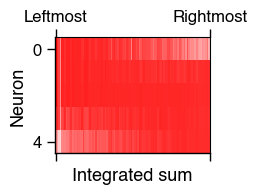

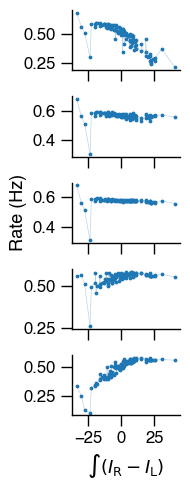

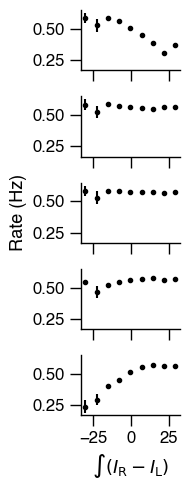

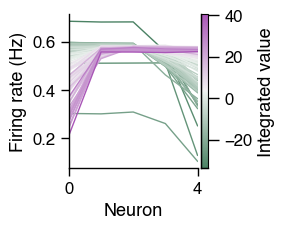

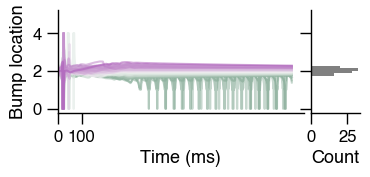

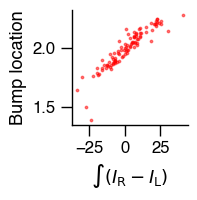

In [19]:
for i, dp in enumerate(DATA_PATHS_NO_HET_LONG):
    for k in np.arange(8, 10):
        last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{k}.npy', last_n=100)
        make_tuning_curves(
            last_100_r,
            all_int_values,
            save_name=f'./figures/n5_no_het_long_{i}_index_{k}',
        )
        make_stability_plot(last_100_r, all_int_values, save_name=f'./figures/n5_no_het_long_{i}_index_{k}')

In [21]:
def plot_raw_activity(dp, index, save_name=None):
    scale = 5
    inputs_raw = load_numpy(os.path.join(dp, f'inputs/net_00{index}.npy')).squeeze(0)
    print(inputs_raw.shape)
    inputs = np.concatenate([np.zeros((100, 200, inputs_raw.shape[2])), inputs_raw[-100:, ...]], axis=1)
        
    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        
        if i % 5 == 0 or i == len(all_int_values[:, -1]) - 1:
            # Create single figure with 3 subplots
            fig, axs = plt.subplots(3, 1, figsize=(0.5 * scale, 0.4 * scale), 
                                    sharex=True,
                                    gridspec_kw={'height_ratios': [0.5, 0.5, 2]})
            
            # Top two subplots for inputs
            axs[0].matshow(inputs[j, :, :CELL_TYPE_1_SIZE].T, cmap='binary', vmin=0, vmax=30, aspect='auto')
            axs[1].matshow(inputs[j, :, CELL_TYPE_1_SIZE:].T, cmap='binary', vmin=0, vmax=30, aspect='auto')
            
            # Bottom subplot for activity trace
            m = np.abs(last_100_r[:, j, :]).max()
            axs[2].matshow(last_100_r[:, j, :], cmap='bwr', vmin=-1.1 * m, vmax=1.1 * m, aspect='auto')
            
            # Format all subplots
            for k in range(3):
                if k == 0:
                    axs[k].set_ylabel(r'$I_R$')
                elif k == 1:
                    axs[k].set_ylabel(r'$I_L$')
                else:
                    axs[k].set_ylabel('Neuron')
                    
                axs[k].set_yticks([])
                axs[k].tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
                axs[k].xaxis.set_label_position('bottom')
            
            # X-axis formatting
            axs[0].set_xticklabels([])
            axs[1].set_xticklabels([])
            axs[2].set_xticks(np.arange(0, 2501, 2500), (np.arange(0, 2501, 2500) / 10).astype(int))
            axs[2].set_xlabel('Time (ms)')

            axs[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
            axs[1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
            
            format_plot(axs, rightspine=True, topspine=True)
            plt.tight_layout()

            if save_name is not None:
                fig.savefig(save_name, bbox_inches='tight')
            
            # fig.savefig(f'./figures/250ms_no_het_combined_{i}.svg', bbox_inches='tight')

(420, 2799, 10)


/tmp/ipykernel_30756/3797718403.py:11: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



(420, 2799, 10)
(420, 2799, 10)
(420, 2799, 10)


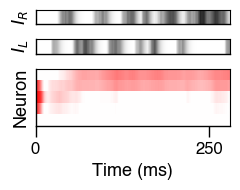

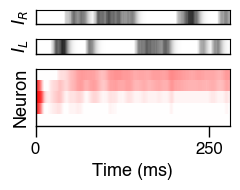

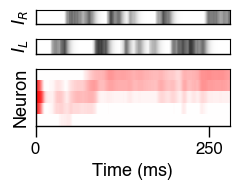

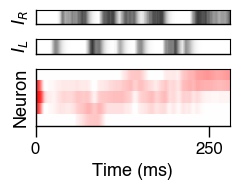

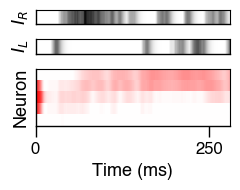

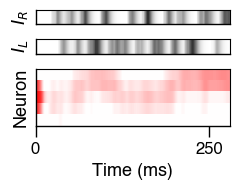

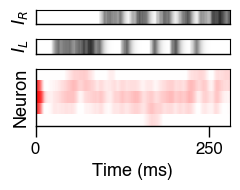

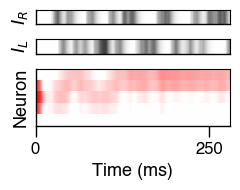

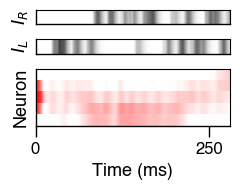

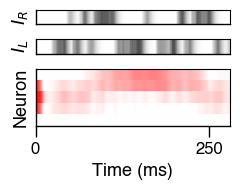

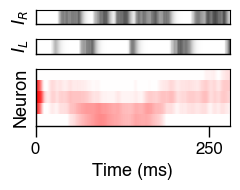

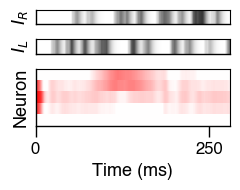

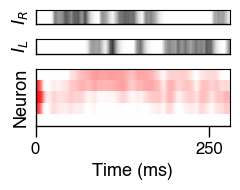

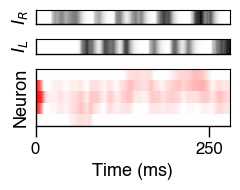

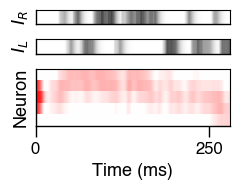

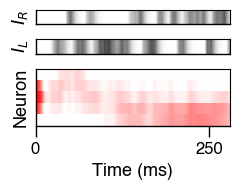

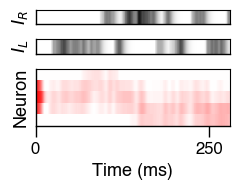

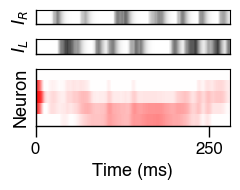

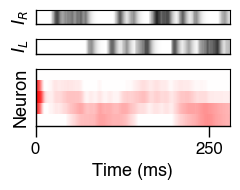

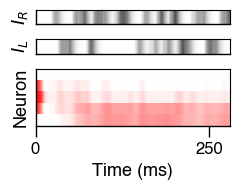

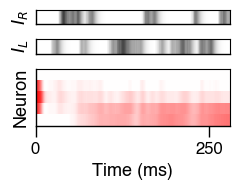

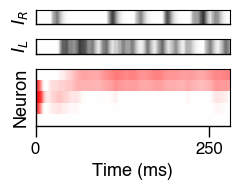

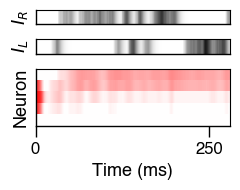

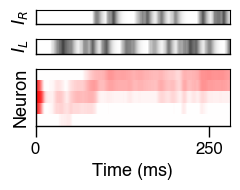

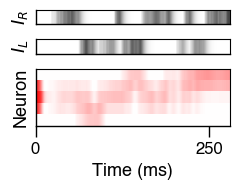

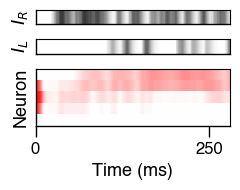

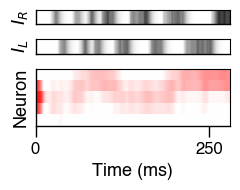

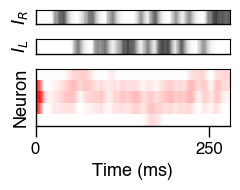

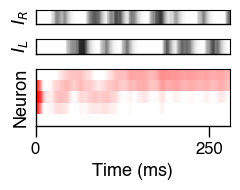

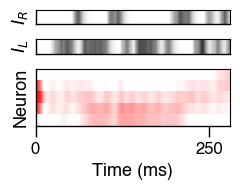

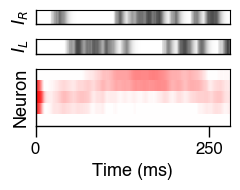

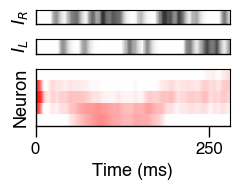

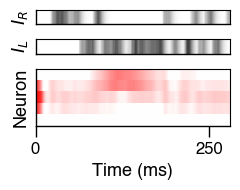

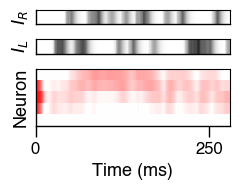

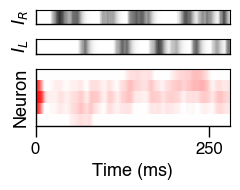

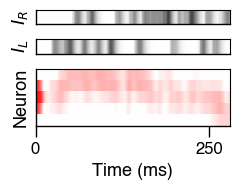

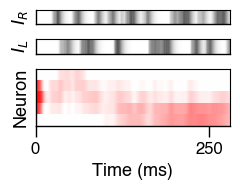

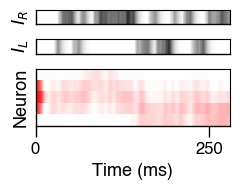

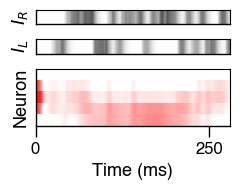

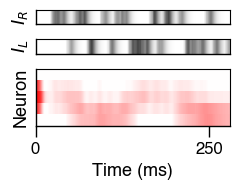

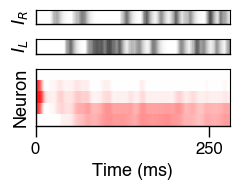

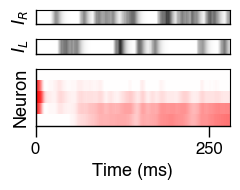

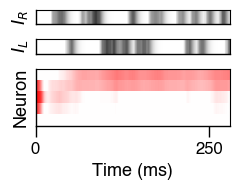

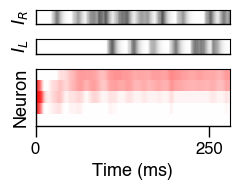

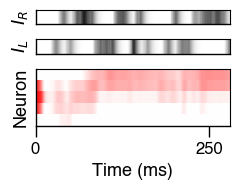

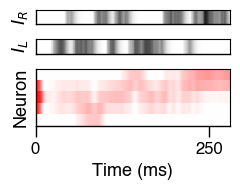

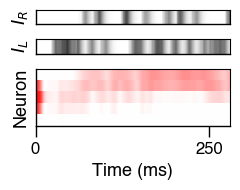

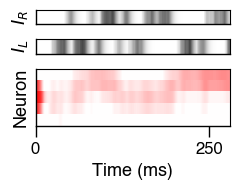

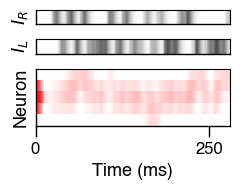

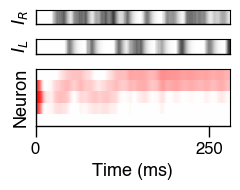

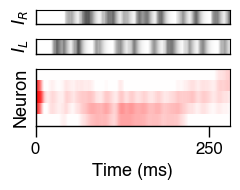

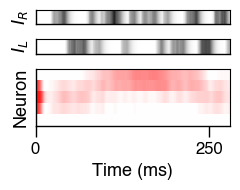

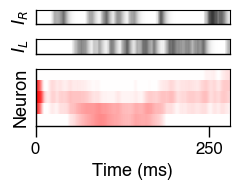

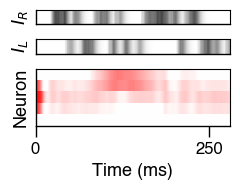

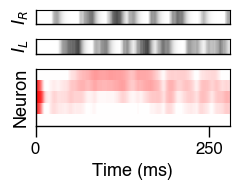

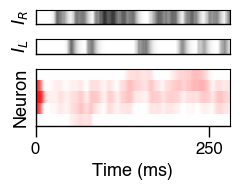

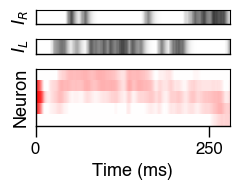

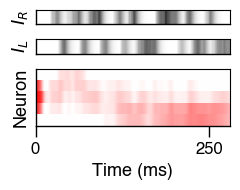

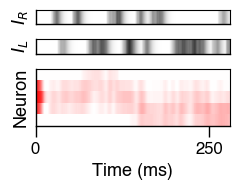

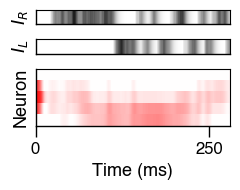

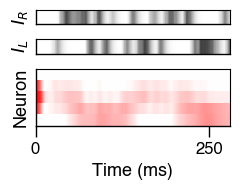

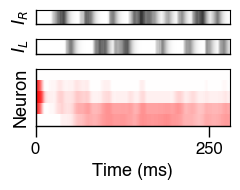

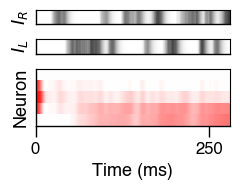

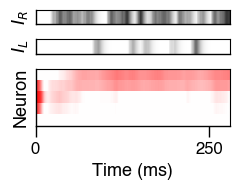

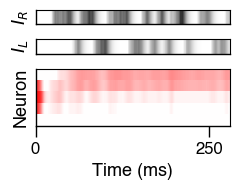

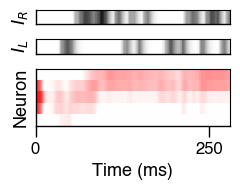

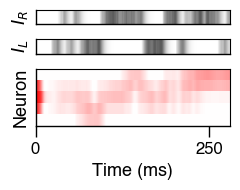

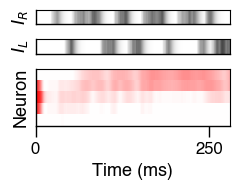

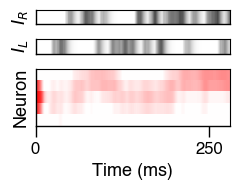

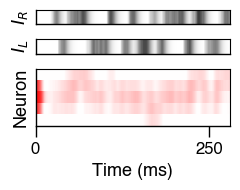

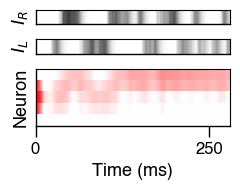

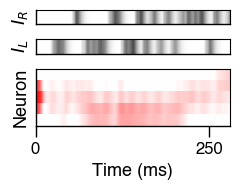

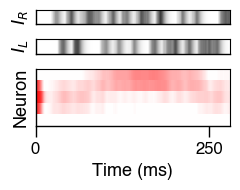

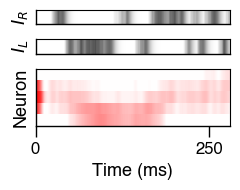

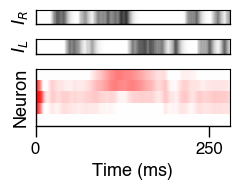

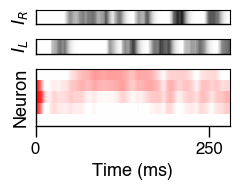

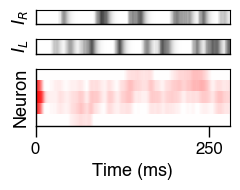

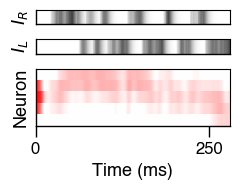

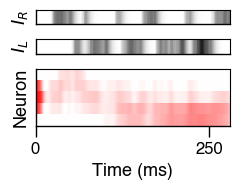

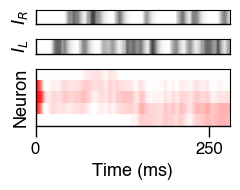

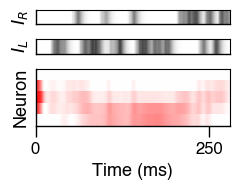

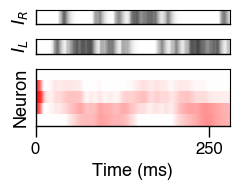

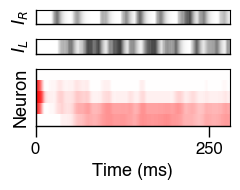

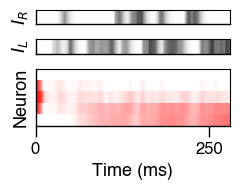

In [15]:
index = 9
for i, dp in enumerate(DATA_PATHS):
    plot_raw_activity(dp, index=index, save_name=f'./figures/n5_no_het_short_activity_trace_{i}_index_{index}.svg')
    # for k in np.arange(0, 10):
    #     last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{k}.npy', last_n=100)

(420, 2799, 10)


/tmp/ipykernel_30756/3797718403.py:11: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



(420, 2799, 10)
(420, 2799, 10)


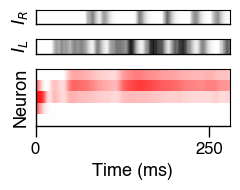

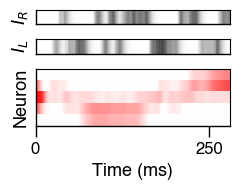

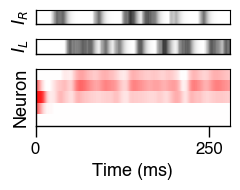

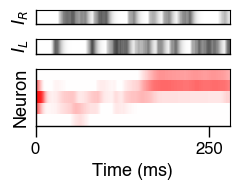

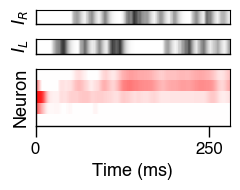

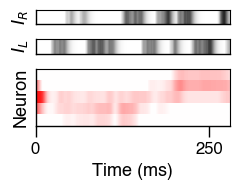

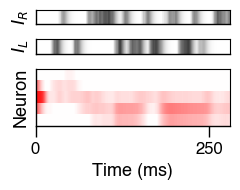

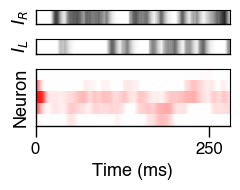

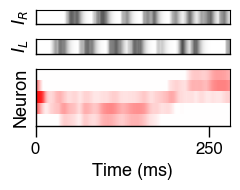

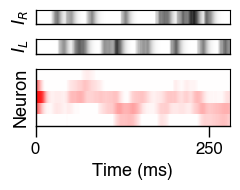

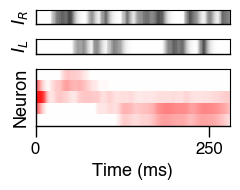

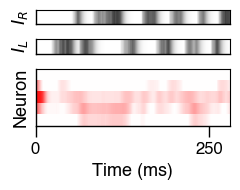

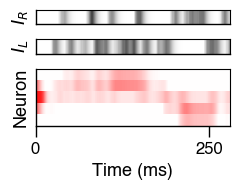

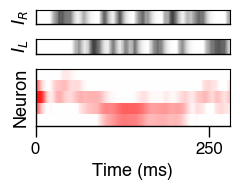

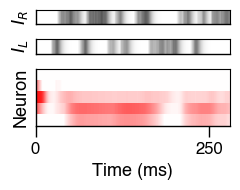

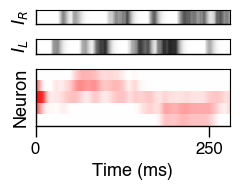

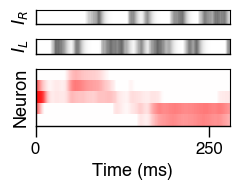

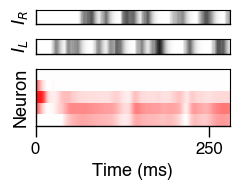

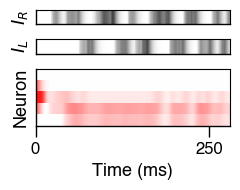

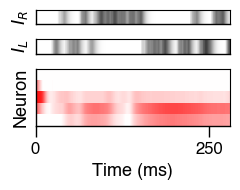

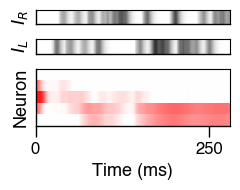

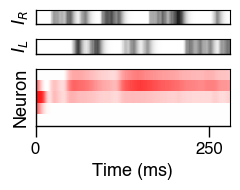

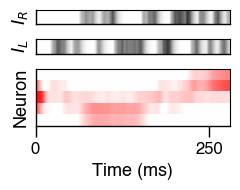

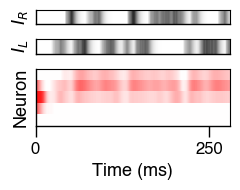

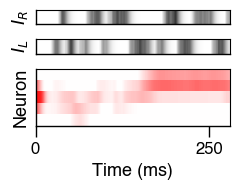

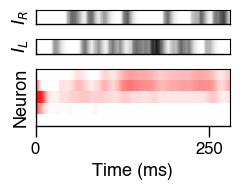

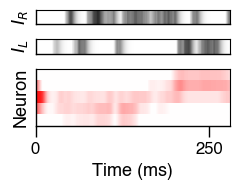

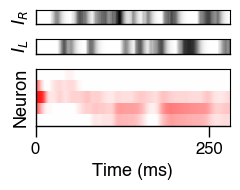

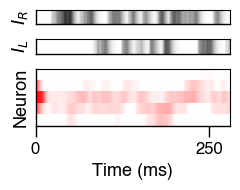

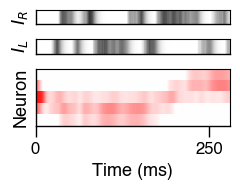

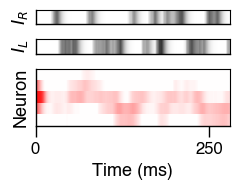

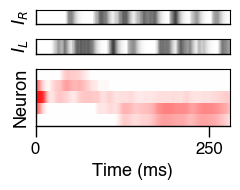

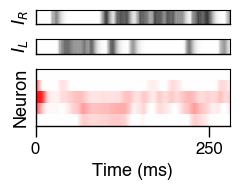

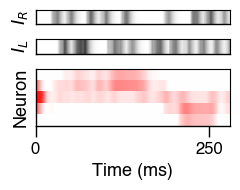

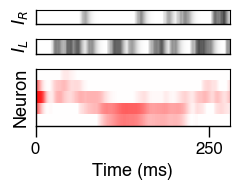

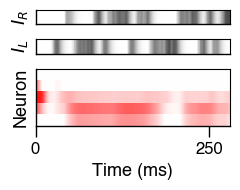

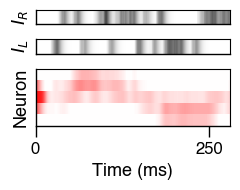

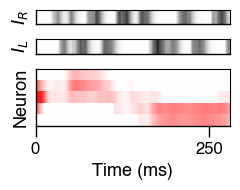

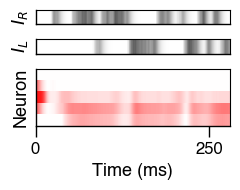

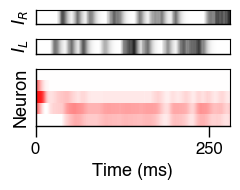

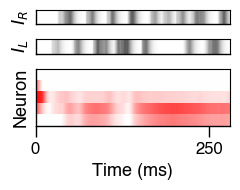

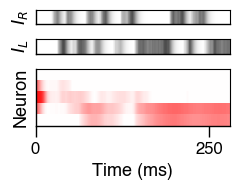

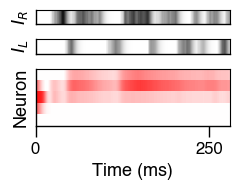

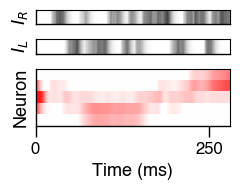

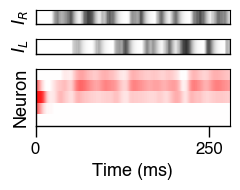

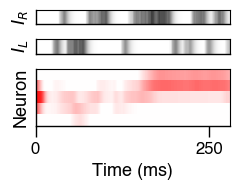

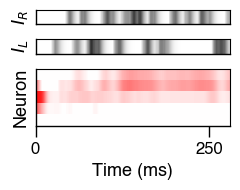

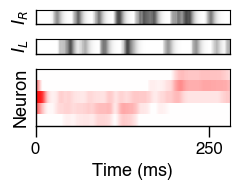

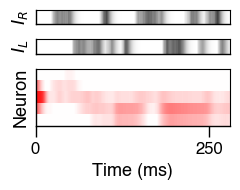

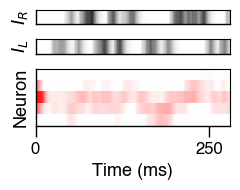

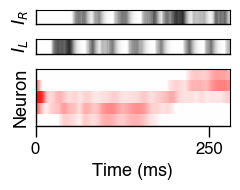

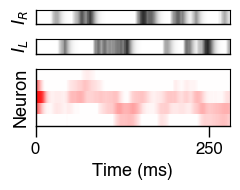

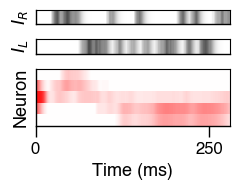

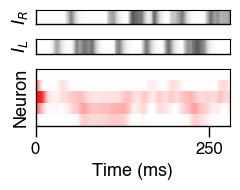

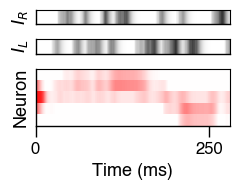

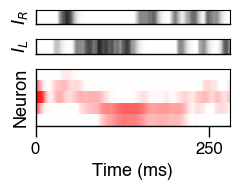

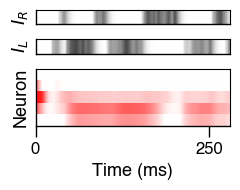

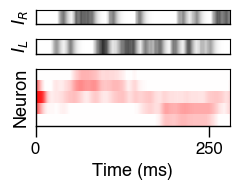

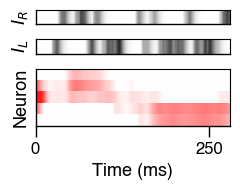

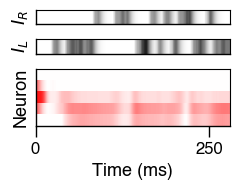

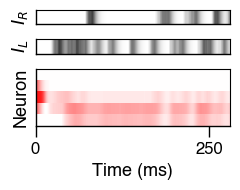

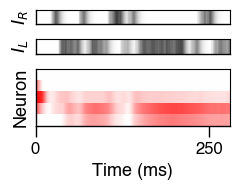

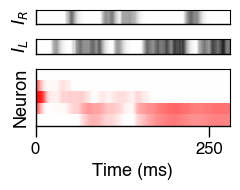

In [33]:
index = 9
for i, dp in enumerate(DATA_PATHS_HET_SHORT):
    plot_raw_activity(dp, index=index, save_name=f'./figures/n5_het_short_activity_trace_{i}_index_{index}.svg')

(420, 9800, 10)


/tmp/ipykernel_3405132/3797718403.py:11: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



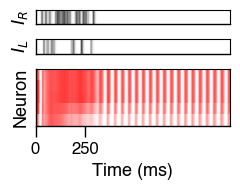

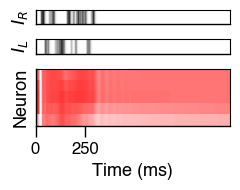

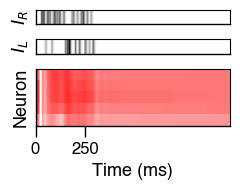

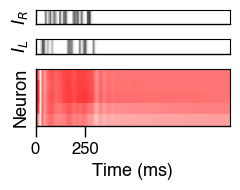

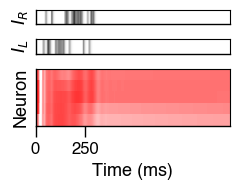

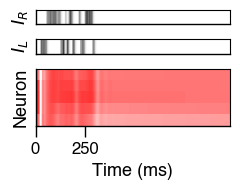

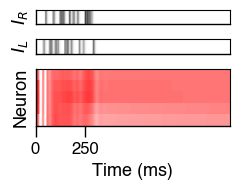

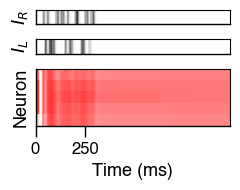

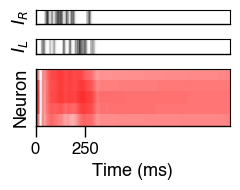

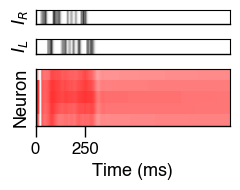

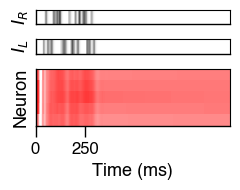

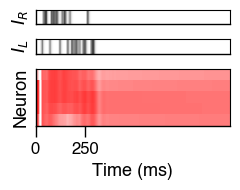

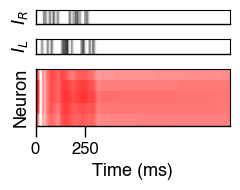

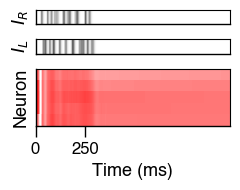

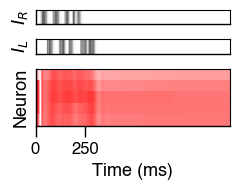

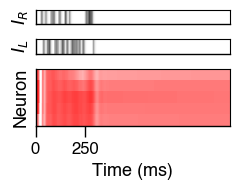

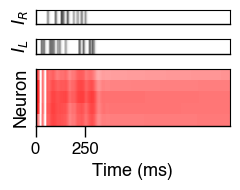

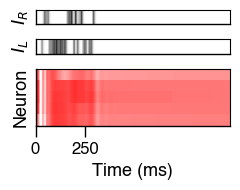

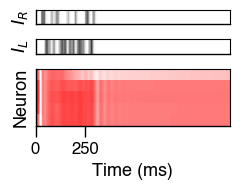

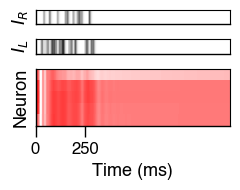

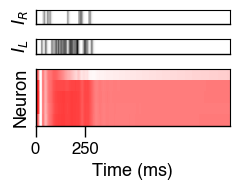

In [22]:
index = 9
for i, dp in enumerate(DATA_PATHS_NO_HET_LONG):
    plot_raw_activity(dp, index=index, save_name=f'./figures/n5_no_het_long_activity_trace_{i}_index_{index}.svg')